In [1]:
!pip install fastai opencv-python tqdm imutils -q
!pip install wandb

In [2]:
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

In [3]:
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
import cv2
import fastai
from fastai.vision.all import *
from fastai.basics import *
from fastai.callback.all import *
import imutils
import torch
import ast
from pathlib import Path
from google.colab import drive
from sklearn.model_selection import train_test_split
from fastai.callback.wandb import WandbCallback
from fastai.callback.tracker import SaveModelCallback, EarlyStoppingCallback
import json
import wandb
from google.colab import userdata

In [5]:
drive.mount('/content/drive')

Mounted at /content/drive


### Connect notebook to WanDB

In [24]:
wandb.login(
    key=userdata.get('WANDB_API_KEY')
)
wandb.init(project="Dartsify AI",name="resnet34_r10_vertical_900_v2repartition")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


### Load Dataset

In [7]:
!mkdir data
!cp -v "drive/My Drive/Dartsify/dataset900_all.zip" "data"
!unzip -q -d data data/dataset900_all.zip

!cp -v "drive/My Drive/Dartsify/label900.csv" "data"

!mkdir -p data/masks

'drive/My Drive/Dartsify/dataset900_all.zip' -> 'data/dataset900_all.zip'
'drive/My Drive/Dartsify/label900.csv' -> 'data/label900.csv'


In [8]:
# Lire les annotations à partir du fichier csv
# ID : nom unique de l'image
# Position : format d'un dictionnaire avec les coordonnées des points de la cible et des fléchettes
# Exemple de Position : "{'objects': {'point': {'x': x1, 'y': y1}}}"
df = pd.read_csv('data/label900.csv')[['ID', 'Position']]

# Supprimer les lignes qui n'ont pas d'ID
df = df.dropna(subset=["ID"])

dataset_path = Path('data/dataset900_all/')
mask_path = Path('data/masks/')


df["image_path"] = df["ID"].apply(
    lambda x: dataset_path / x
)

df["mask_path"] = df["ID"].apply(
    lambda x: mask_path / x
)

df.head(2)

,,,,,ID,Position,image_path,mask_path
cam1_020526_124044.jpg,"{""objects"":[{""point"":{""x"":593.3",y:241.9}},"{""point"":{""x"":822.7",y:316.0}},"{""point"":{""x"":592.6",y:352.2}}]},"data/dataset900_all/{""point"":{""x"":592.6","data/masks/{""point"":{""x"":592.6"
cam1_020526_124100.jpg,"{""objects"":[{""point"":{""x"":368.0",y:294.0}},"{""point"":{""x"":449.4",y:236.9}},"{""point"":{""x"":377.6",y:220.1}}]},"data/dataset900_all/{""point"":{""x"":377.6","data/masks/{""point"":{""x"":377.6"


In [9]:
%%time
def read_label_rows(label_path: Path):
  rows = []
  with label_path.open('r', encoding='utf-8') as csv_file:
    lines = csv_file.read().splitlines()

  for line in lines[1:]:
    if not line.strip():
      continue
    image_id, _, position_text = line.partition(',')
    rows.append((image_id.strip().strip('"'), position_text.strip()))
  return rows


def parse_position(position_text: str):
  text = position_text.strip()
  if not text or text == '""':
    return []
  if text.startswith('"') and text.endswith('"'):
    text = text[1:-1]

  data = json.loads(text)
  points = []
  for item in data.get('objects', []):
    point = item.get('point')
    if isinstance(point, dict) and {'x', 'y'} <= point.keys():
      points.append((float(point['x']), float(point['y'])))
      continue
    for value in item.values():
      if isinstance(value, dict) and {'x', 'y'} <= value.keys():
        points.append((float(value['x']), float(value['y'])))
        break
  return points


rows = []
for image_id, position_text in read_label_rows(Path('data/label900.csv')):  # O(n) pour parcourir les lignes du fichier label.csv (normalement 300 lignes)
  try:
    points = parse_position(position_text)
  except json.JSONDecodeError:
    print('Aucune position détectée', image_id)
    points = []

  image_full_path = dataset_path / image_id

  nom_base = os.path.splitext(image_id)[0]
  mask_filename = f"{nom_base}.png"
  mask_full_path = mask_path / mask_filename

  rows.append((
      image_id,
      points,
      image_full_path,
      mask_full_path
  ))

df = pd.DataFrame(rows, columns=['ID', 'center_point', 'image_path', 'mask_path'])
print(df[['ID', 'center_point', 'image_path', 'mask_path']].sample(3))
print(df.columns)

                         ID                                      center_point  \
98   cam1_040526_190045.jpg                                  [(742.7, 236.0)]   
765  cam2_090426_020516.jpg  [(606.5, 231.8), (702.7, 252.6), (566.3, 342.6)]   
212  cam2_020526_124335.jpg  [(600.6, 196.3), (564.5, 222.8), (518.7, 228.8)]   

                                     image_path  \
98   data/dataset900_all/cam1_040526_190045.jpg   
765  data/dataset900_all/cam2_090426_020516.jpg   
212  data/dataset900_all/cam2_020526_124335.jpg   

                             mask_path  
98   data/masks/cam1_040526_190045.png  
765  data/masks/cam2_090426_020516.png  
212  data/masks/cam2_020526_124335.png  
Index(['ID', 'center_point', 'image_path', 'mask_path'], dtype='object')
CPU times: user 319 ms, sys: 932 µs, total: 320 ms
Wall time: 319 ms


### Create Masks

In [25]:
radius = 10
thickness = -1
color = 1 # pixel de la pointe de la fléchètte à 1 et le reste de l'image à 0
h, w = 720, 1280

for row in df.itertuples(): # Utilisation de itertuples pour des performances potentiellement meilleures et une meilleure lisibilité
  # Vérifie si 'center_point' existe pour la ligne actuelle
  if row.center_point is None:
    print(f"Impossible de créer un masque de segmentation pour l'image {row.ID} car pas aucun label des positions des fléchèttes.")
    continue

  img = np.zeros((h, w), np.uint8)
  for point in row.center_point:
    x, y = point
    center_coordinates = (int(x), int(y)) # S'assurer que les coordonnées sont des entiers pour cv2.circle
    img = cv2.circle(img, center_coordinates, radius, color, thickness)

  # On s'assure de sauvegarder en .png pour éviter la compression JPEG
  # (Si row.ID s'appelle "photo_01.jpg", on le remplace par "photo_01.png")
  mask_filename = os.path.splitext(row.ID)[0]
  cv2.imwrite(f"{mask_path}/{mask_filename}.png", img)

### Afficher quelques masques de segmentation pour l'entrainement

Displaying 2 segmentation masks:

Example: data/masks/cam2_080426_221723.png (720, 1280)


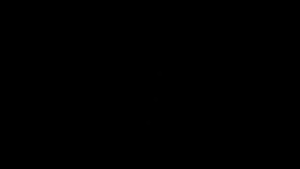


Example: data/masks/cam1_040526_185812.png (720, 1280)


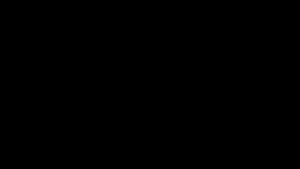

In [26]:
# Sélectionner les lignes où 'center_point' n'est pas None et les masques ont probablement été créés
df_with_masks = df[df['center_point'].notna()]

sampled_masks = df_with_masks.sample(2)

print(f"Displaying {2} segmentation masks:")

# En supposant que 'mask_path' est déjà défini à partir de la cellule précédente
# Si 'mask_path' n'est pas défini, il peut être nécessaire de le redéfinir ici : mask_path = Path('data/masks/')

for index, row in sampled_masks.iterrows():
    nom_base = os.path.splitext(row.ID)[0]
    mask_filename = f"{nom_base}.png"
    # mask_filename = row['ID']
    mask_file_path = mask_path/mask_filename
    if mask_file_path.exists():
        im = PILImage.create(mask_file_path)
        print(f"\nExample: {mask_file_path} {im.shape}")
        display(im.to_thumb(300))
    else:
        print(f"Mask file not found for {mask_filename}")

### Dataloader `get` Functions

In [27]:
def get_x(row):
    return row['image_path']

def get_mask(row):
    return row['mask_path']

### Create val, train and test data



In [28]:
# version 1
# Sur 900 images :
# 700 pour train
# 100 pour val
# 100 pour test

# version 2
# Sur 900 images :
# 500 pour train
# 300 pour val
# 100 pour test

# Séparer les données de test
df_trainval, df_test = train_test_split(df, test_size=100, random_state=42, shuffle=True)

# Séparer les données d'entraînement et de validation
df_train, df_val = train_test_split(
    df_trainval,
    test_size=300,
    random_state=42,
    shuffle=True
)

# Créer les indices pour les données de validation pour avoir exactement 100 images
df_trainval = pd.concat([df_train, df_val])
valid_idx = list(range(len(df_train), len(df_trainval)))

# Transformations (ancienne version)
# tfms = [
#     Rotate(max_deg=10),
#     Zoom(),
#     # Warp(),
#     Brightness(max_lighting=0.3),
#     Flip(),
#     Contrast(max_lighting=0.3),
#     Normalize.from_stats(*imagenet_stats)
# ]

# Entraînement / Validation avec RandomSplitter
d_unet = DataBlock(
    blocks=(ImageBlock, MaskBlock),
    get_x=get_x,
    get_y=get_mask,
    # item_tfms=RandomCrop(512), # Reduced image size to save memory
    splitter=IndexSplitter(valid_idx),
    batch_tfms=[
      # Augmente fortement les variations de lumière, contraste et rotation
      *aug_transforms(
          mult=1.5,             # rend les déformations un peu plus fortes
          do_flip=True,         # Miroir horizontal
          flip_vert=True,       # Miroir vertical
          max_rotate=30.0,      # Rotation
          max_zoom=1.2,         # Zoom léger
          max_lighting=0.4,     # Pousse la luminosité/contraste
          max_warp=0.2,         # Déformation de perspective
          p_lighting=0.75       # Applique les changements de lumière sur 75% des images
      ),
      RandomCrop(512),
      Normalize.from_stats(*imagenet_stats)
    ]
)

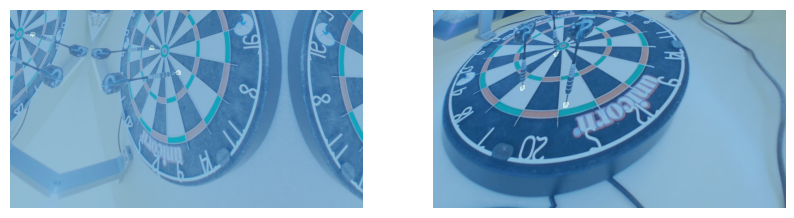

In [29]:
# La taille du lot est passée dans le dataloader
# Attention à l'overfitting et à l'utilisation excessive de la mémoire GPU
BATCH_SIZE = 2
# dls pour DataLoaders
dls = d_unet.dataloaders(df_trainval, bs=BATCH_SIZE)
dls.show_batch(max_n=2, figsize=(10,10))

### Inspection des masques car souvent on trouve pixel à 2 (normalement le masque doit être binaire)

In [30]:
import numpy as np
import cv2

# Prenez le chemin d'un ou plusieurs masques générés
chemin_test = df_trainval['mask_path'].iloc[5] # Adaptez selon votre dataframe
masque_test = cv2.imread(chemin_test, cv2.IMREAD_GRAYSCALE)

print("Valeurs uniques dans le masque :", np.unique(masque_test))
# Si ça affiche [0, 1, 2], le coupable est bien là !

Valeurs uniques dans le masque : [0 1]


### Create `UNet` Learner

In [31]:
# Meilleurs Hyperparamètres
BEST_GAMMA = 4.437892927205953
BEST_WD = 3.5639359903428303e-05
BEST_LR = 0.0007539865498213478

In [32]:
learn = unet_learner(
    dls=dls,
    arch=resnet34,
    metrics=[DiceMulti, JaccardCoeffMulti], # metrics adaptés pour la segmentation binaire
    loss_func=FocalLossFlat(axis=1, gamma=BEST_GAMMA), # optuna results --- cette loss force le modèle à se concentrer sur les pixels rares car dataset déséquilibré
    self_attention=True,
    act_cls=Mish,
    pretrained=True,
    blur_final=True,
    opt_func=ranger,
    n_out=2
    ).to_fp16() # Activer l'entraînement en précision mixte pour réduire la consommation de mémoire GPU


### Training Model

### Déterminer le meilleur pas d'apprentissage avec un LR finder

<div></div>

le bon pas d'apprentissage (lr) 0.00013182566908653826
CPU times: user 6min 15s, sys: 49.7 s, total: 7min 4s
Wall time: 20.8 s


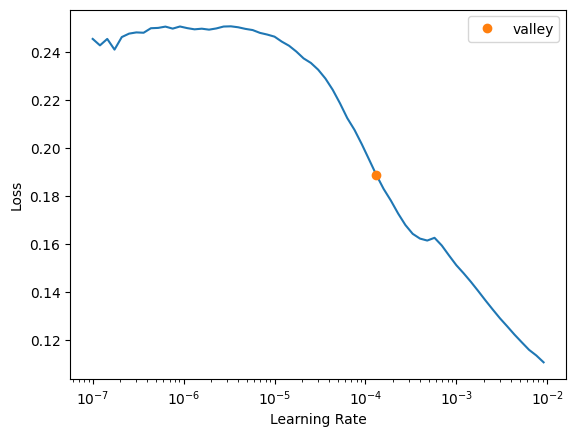

In [ ]:
%%time
# Résumé du modèle (architecture, couche, nb paramètres, ...)
# learn.summary()

# Détermine le bon learning_rate via un learning rate finder
# lr = learn.lr_find().valley
# print("le bon pas d'apprentissage (lr)",lr)

### Lancer l'entrainement

In [1]:
# Lancer l'entraînement du modèle
EPOCHS = 15

early_stopping_callback = EarlyStoppingCallback(monitor="jaccard_coeff_multi", patience=3)
checkpoint_callback = SaveModelCallback(
    monitor='jaccard_coeff_multi', comp=np.greater
)

# fit one cycle ajuste dynamiquement le taux d'apprentissage entre une valeur basse et maximale tout au long de l'entraînement
learn.fit_one_cycle(
    EPOCHS,
    slice(BEST_LR),
    pct_start=0.9, # 90% du temps d'entraînement à augmenter lr
    wd=BEST_WD,
    cbs=[
        early_stopping_callback,
        checkpoint_callback,
        WandbCallback()
    ]
)

NameError: name 'EarlyStoppingCallback' is not defined

### Fin de l'entrainement

In [19]:
wandb.finish()

beta_0,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
beta_1,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
beta_2,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
dice_multi,▁▅▆▇▇▇▇████
epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇████
eps_0,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eps_1,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eps_2,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
jaccard_coeff_multi,▁▄▅▆▆▆▆███▇
lr_0,▁▁▁▁▁▁▁▁▁▁▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇███
+15,...


### Enregistrer le modèle

In [ ]:
learn.save('dartsify_ai_resnet34_radius15_vertical_900_v2repartition')
!cp "models/dartsify_ai_resnet34_radius15_vertical_900_v2repartition.pth" "drive/My Drive/Dartsify/models/"

### Afficher les résultats de prédiction

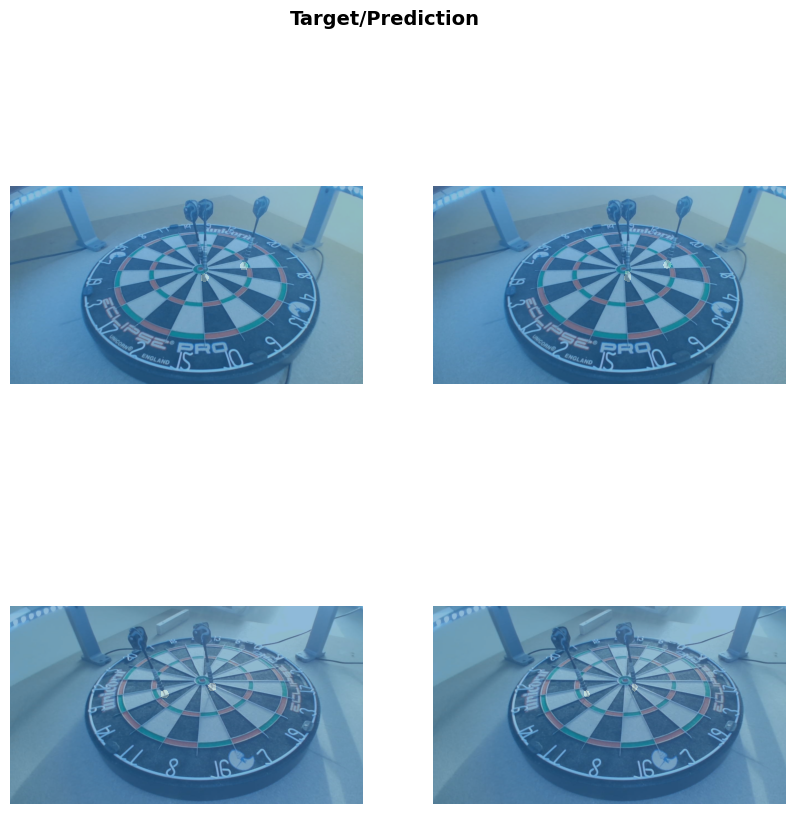

In [20]:
learn.show_results(ds_idx=1, max_n=10, figsize=(10,10))

### Tester le modèle exporté avec les données de test

In [ ]:
# learn = load_learner("drive/My Drive/Dartsify/models/dartsify_ai_final.pkl")

/usr/local/lib/python3.12/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


In [ ]:
# NETTOYAGE CRITIQUE : On supprime les callbacks d'entraînement pour l'inférence
# if WandbCallback in [type(cb) for cb in learn.cbs]:
#     learn.remove_cb(WandbCallback)

# if SaveModelCallback in [type(cb) for cb in learn.cbs]:
#     learn.remove_cb(SaveModelCallback)

# if EarlyStoppingCallback in [type(cb) for cb in learn.cbs]:
#     learn.remove_cb(EarlyStoppingCallback)

Évaluation en cours sur le jeu de test...


Score Dice final (Test)    : 0.8832
Score Jaccard final (Test) : 0.8105

Affichage d'un échantillon des prédictions :


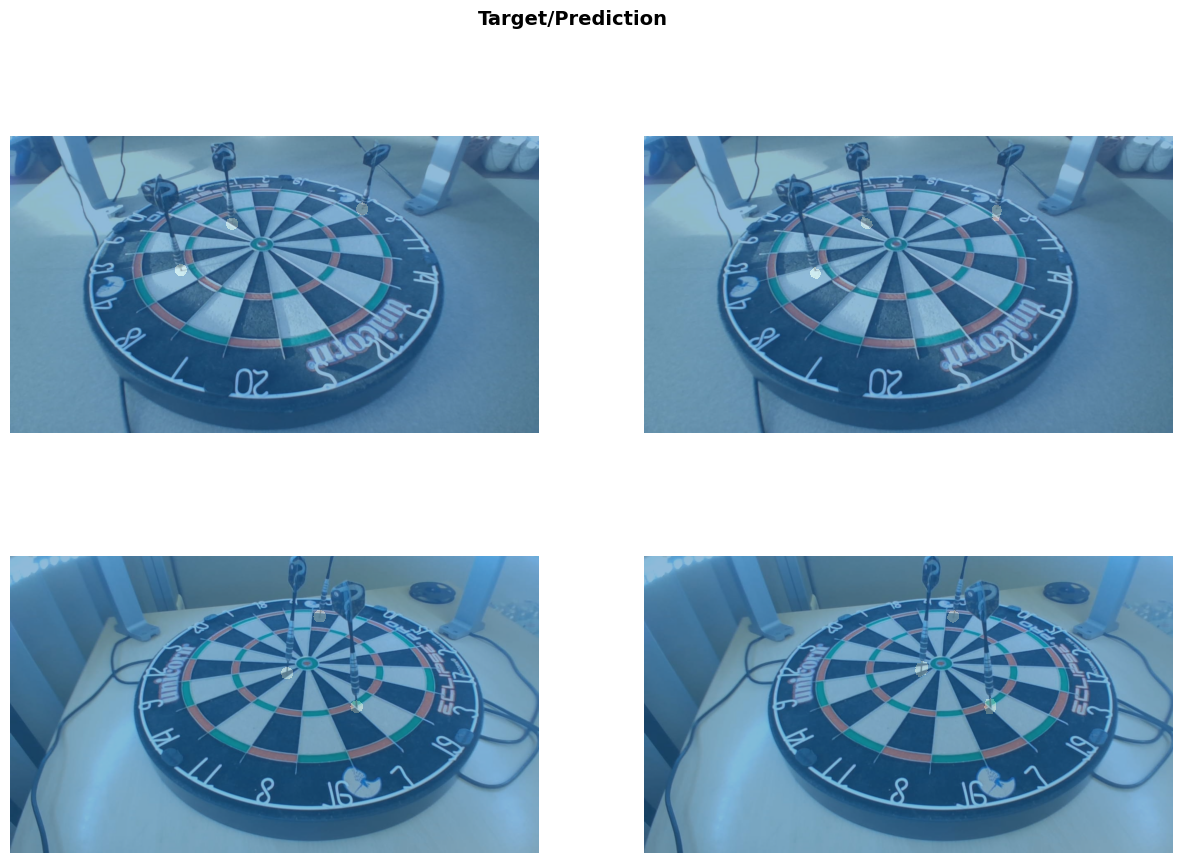

In [21]:
# Création du DataLoader de test à partir de votre df_test
dl_test = learn.dls.test_dl(df_test, with_labels=True)

print("Évaluation en cours sur le jeu de test...")
resultats_test = learn.validate(dl=dl_test)

# Index 0 = Loss (FocalLoss)
# Index 1 = DiceMulti
# Index 2 = JaccardCoeffMulti (IoU)
print(f"Score Dice final (Test)    : {resultats_test[1]:.4f}")
print(f"Score Jaccard final (Test) : {resultats_test[2]:.4f}")

# 3. Évaluation visuelle (Comparaison : Vrai masque | Prédiction de l'IA)
print("\nAffichage d'un échantillon des prédictions :")
learn.show_results(dl=dl_test, max_n=4, figsize=(15, 10))

In [ ]:
preds, _ = learn.get_preds()

In [ ]:
print(preds)

TensorBase([[[[0.8424, 0.8769, 0.9100,  ..., 0.8883, 0.8772, 0.8235],
              [0.8621, 0.8833, 0.9081,  ..., 0.8823, 0.8772, 0.8498],
              [0.8874, 0.9025, 0.9237,  ..., 0.8735, 0.8699, 0.8608],
              ...,
              [0.8771, 0.8939, 0.8965,  ..., 0.9578, 0.9435, 0.9349],
              [0.8661, 0.8859, 0.8911,  ..., 0.9401, 0.9258, 0.9191],
              [0.8497, 0.8608, 0.8772,  ..., 0.9353, 0.9098, 0.8961]],

             [[0.1576, 0.1231, 0.0900,  ..., 0.1117, 0.1228, 0.1765],
              [0.1379, 0.1167, 0.0919,  ..., 0.1177, 0.1228, 0.1502],
              [0.1126, 0.0975, 0.0763,  ..., 0.1265, 0.1301, 0.1392],
              ...,
              [0.1229, 0.1061, 0.1035,  ..., 0.0422, 0.0565, 0.0651],
              [0.1339, 0.1141, 0.1089,  ..., 0.0599, 0.0742, 0.0809],
              [0.1503, 0.1392, 0.1228,  ..., 0.0647, 0.0902, 0.1039]]],


            [[[0.8291, 0.8712, 0.9022,  ..., 0.8727, 0.8584, 0.8181],
              [0.8539, 0.8839, 0.9077,  ..., 0

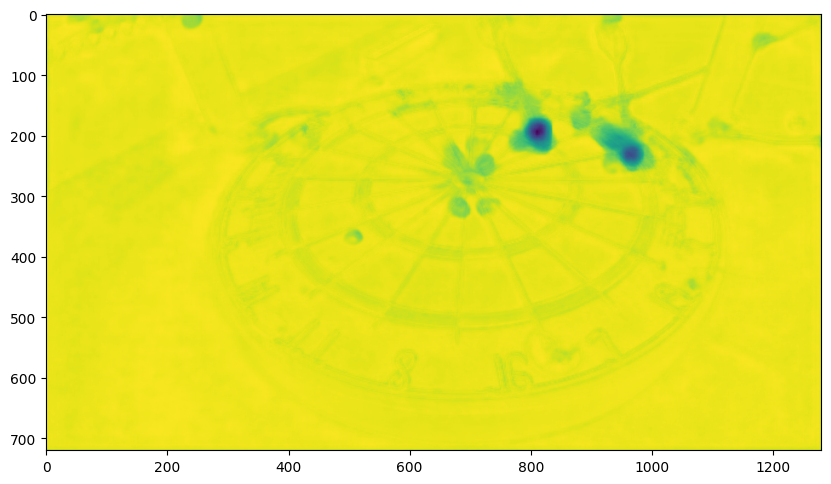

In [ ]:
# Example Unet prediction mask

plt.figure(figsize = (10, 10))
plt.imshow(preds[50].numpy()[0])

### Exporter le modèle


In [22]:
learn.export("dartsify_ai_r15_vertical_v2repartition.pkl")

In [23]:
%cp dartsify_ai_r15_vertical_v2repartition.pkl "drive/My Drive/Dartsify/models/dartsify_ai_r15_vertical_v2repartition.pkl"

### Charger le modèle

In [ ]:
learn_inf = load_learner("drive/My Drive/Dartsify/models/dartsify_ai_resnet34_radius10.pkl")

/usr/local/lib/python3.12/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


In [ ]:
# NETTOYAGE CRITIQUE : On supprime les callbacks d'entraînement pour l'inférence
if WandbCallback in [type(cb) for cb in learn.cbs]:
		learn.remove_cb(WandbCallback)

if SaveModelCallback in [type(cb) for cb in learn.cbs]:
  learn.remove_cb(SaveModelCallback)

if EarlyStoppingCallback in [type(cb) for cb in learn.cbs]:
  learn.remove_cb(EarlyStoppingCallback)

In [ ]:
# ON DÉSACTIVE LE CENTERCROP FANTÔME DE FASTAI
# 1. On filtre la liste des transformations pour retirer les "Crop"
transformations_sans_crop = [tfm for tfm in learn.dls.after_item.fs if 'Crop' not in type(tfm).__name__]

# 2. On recrée le Pipeline avec les transformations restantes (ex: ToTensor)
learn.dls.after_item = Pipeline(transformations_sans_crop)


### Debug : Vérifier s'il arrive à trouver les pointes de la fléchette avec toutes les images du dataset

In [ ]:
import glob

In [ ]:
%%time
for i in glob.glob("drive/My Drive/Dartsify/dataset/*"):
  out = learn_inf.predict(i)
  if out[0].numpy().sum() > 0:
    print(i)
    break


### FINE TUNE

In [ ]:
checkpoint = SaveModelCallback(monitor='jaccard_coeff_multi', comp=np.greater) # On allonge l'entrainement en évitant le surapprentissage
early_stopping = EarlyStoppingCallback(monitor="jaccard_coeff_multi", patience=3)

learn = unet_learner(
    dls=dls,
    arch=resnet34,
    metrics=[DiceMulti(), JaccardCoeffMulti()],
    loss_func=FocalLossFlat(axis=1, gamma=BEST_GAMMA),
    wd=BEST_WD,
    self_attention=True,
    act_cls=Mish,
    pretrained=True,
    blur_final=True,
    opt_func=ranger,
    n_out=2,
    cbs=[checkpoint, early_stopping, WandbCallback()]
).to_fp16()

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 181MB/s]


In [ ]:
ancien_modele = load_learner("drive/My Drive/Dartsify/models/dartsify_ai_resnet34_radius15_vertical.pkl")

# On copie les poids mathématiques de l'ancien vers le nouveau
learn.model.load_state_dict(ancien_modele.model.state_dict())

# On n'a plus besoin de l'ancien, on libère la mémoire
del ancien_modele
import gc; gc.collect()

7488

In [ ]:
# ENTRAÎNEMENT EN DEUX PHASES
# On gèle l'encodeur profond (qui sait déjà reconnaître les textures de fléchettes)
# On n'entraîne que les dernières couches pour qu'elles s'adaptent au mur
learn.freeze()

# 2 époques suffisent généralement pour la première adaptation
learn.fit_one_cycle(2, lr_max=BEST_LR, wd=BEST_WD)


# On débloque tout le réseau pour un ajustement millimétrique
learn.unfreeze()


# On utilise des Learning Rates très faibles pour ne pas "détruire"
# ce que le modèle avait appris lors de sa première vie sur la table.
# slice(1e-5, 1e-4) signifie : apprentissage infime sur les premières couches,
# et très léger sur les dernières.
lr_debut = BEST_LR / 100
lr_fin = BEST_LR / 10

learn.fit_one_cycle(5, lr_max=slice(lr_debut, lr_fin), wd=BEST_WD)

epoch,train_loss,valid_loss,dice_multi,jaccard_coeff_multi,time
0,0.000184,0.000111,0.865721,0.788144,05:24
1,0.000147,0.000084,0.923679,0.867504,05:22


Better model found at epoch 0 with jaccard_coeff_multi value: 0.7881440758332257.
Better model found at epoch 1 with jaccard_coeff_multi value: 0.867504174738427.


epoch,train_loss,valid_loss,dice_multi,jaccard_coeff_multi,time
0,0.000154,0.000083,0.923084,0.866611,05:31
1,0.000144,0.000077,0.925836,0.870768,05:33
2,0.000133,0.000074,0.927210,0.872859,05:32
3,0.000149,0.000074,0.929462,0.876306,05:33
4,0.000131,0.000074,0.929192,0.875891,05:31


Better model found at epoch 0 with jaccard_coeff_multi value: 0.866610772141116.
Better model found at epoch 1 with jaccard_coeff_multi value: 0.8707678415626451.
Better model found at epoch 2 with jaccard_coeff_multi value: 0.8728589334551092.
Better model found at epoch 3 with jaccard_coeff_multi value: 0.8763057995909782.


In [ ]:
wandb.finish()

beta_0,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
beta_1,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
beta_2,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
dice_multi,▁▇▇████
epoch,▁▁▂▂▂▂▂▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▅▅▅▆▆▆▆▆▆▆▆▇▇▇██
eps_0,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eps_1,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eps_2,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
jaccard_coeff_multi,▁▇▇████
lr_0,▃▆██▇▆▅▄▃▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+15,...


In [ ]:
learn.export("dartsify_ai_final_radius15_vertical_ft.pkl")

In [ ]:
%cp dartsify_ai_final_radius15_vertical_ft.pkl "drive/My Drive/Dartsify/models/dartsify_ai_final_radius15_vertical_ft.pkl"

### OPTUNA

In [ ]:
!pip install optuna "optuna-integration[fastai]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 12.4 MB/s eta 0:00:00


In [ ]:
import optuna
from optuna.integration import FastAIPruningCallback
import gc
import torch
from fastai.vision.all import *

In [ ]:
def objective(trial):
    # ---------------------------------------------------------
    # 1. DÉFINITION DES HYPERPARAMÈTRES À TESTER
    # ---------------------------------------------------------
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)

    # wd = pénalité pour éviter le surapprentissage
    wd = trial.suggest_float("wd", 1e-6, 1e-2, log=True)

    gamma_val = trial.suggest_float("gamma", 2.5, 5.0)

    # --- LE CALLBACK DE PRUNING ---
    # Il va surveiller la 'valid_loss' à chaque époque.
    pruning_cb = FastAIPruningCallback(trial, monitor='valid_loss')

    # ---------------------------------------------------------
    # 2. INITIALISATION DES DONNÉES ET DU MODÈLE
    # ---------------------------------------------------------
    local_batch_size = 2 # Using BATCH_SIZE=1 as established to avoid OOM
    dls = d_unet.dataloaders(df_trainval, bs=local_batch_size) # Create dls locally for the objective function

    learn = unet_learner(
        dls=dls,
        arch=resnet34, # On passe le nom en chaîne de caractères pour timm
        metrics=[DiceMulti, JaccardCoeffMulti],
        loss_func=FocalLossFlat(axis=1,gamma=gamma_val), # Changed to BCEWithLogitsFlat for binary segmentation
        wd=wd,
        self_attention=True,
        act_cls=Mish,
        pretrained=True,
        blur_final=True,
        opt_func=ranger,
        n_out=2,
        cbs=[pruning_cb]
    ).to_fp16()

    # ---------------------------------------------------------
    # 3. ENTRAÎNEMENT
    # ---------------------------------------------------------
    with learn.no_bar(), learn.no_logging():
        learn.fine_tune(3, base_lr=lr)

    # ---------------------------------------------------------
    # 4. RÉCUPÉRATION DU SCORE
    # ---------------------------------------------------------
    val_results = learn.validate()
    jaccard_score = val_results[2]

    # ---------------------------------------------------------
    # 5. NETTOYAGE ABSOLU DE LA MÉMOIRE (CRITIQUE)
    # ---------------------------------------------------------
    del learn
    del dls
    torch.cuda.empty_cache()
    gc.collect()

    # Optuna va essayer de maximiser cette valeur !
    return jaccard_score

In [ ]:
# On indique à Optuna qu'on veut MAXIMISER le score retourné (le Jaccard)
# Configuration de l'élagueur
# n_warmup_steps=1 : On laisse au moins 1 époque se terminer avant de juger si c'est mauvais.
study = optuna.create_study(
    direction="maximize",
    study_name="Dartsify_UNet_Optimization",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=1)
    )

# On lance l'optimisation pour 8 essais
study.optimize(objective, n_trials=10)

# Afficher les meilleurs résultats à la fin
print("Meilleur score Jaccard atteint :", study.best_value)
print("Meilleurs hyperparamètres :", study.best_params)

[I 2026-05-06 03:02:27,269] A new study created in memory with name: Dartsify_UNet_Optimization
/usr/local/lib/python3.12/dist-packages/optuna_integration/fastaiv2/fastaiv2.py:71: UserWarning: The reported value is ignored because this `step` 0 is already reported.
  self.trial.report(self.recorder.final_record[self.idx], step=self.epoch)


[I 2026-05-06 03:25:21,857] Trial 0 finished with value: 0.7168674922382364 and parameters: {'lr': 7.395009564585931e-05, 'wd': 0.00017112524680386996, 'gamma': 3.4495311412687024}. Best is trial 0 with value: 0.7168674922382364.
/usr/local/lib/python3.12/dist-packages/optuna_integration/fastaiv2/fastaiv2.py:71: UserWarning: The reported value is ignored because this `step` 0 is already reported.
  self.trial.report(self.recorder.final_record[self.idx], step=self.epoch)


[I 2026-05-06 03:48:38,400] Trial 1 finished with value: 0.5750250685555881 and parameters: {'lr': 1.114286824326273e-05, 'wd': 4.843915785468203e-05, 'gamma': 3.250400563013132}. Best is trial 0 with value: 0.7168674922382364.
/usr/local/lib/python3.12/dist-packages/optuna_integration/fastaiv2/fastaiv2.py:71: UserWarning: The reported value is ignored because this `step` 0 is already reported.
  self.trial.report(self.recorder.final_record[self.idx], step=self.epoch)


[I 2026-05-06 04:11:32,582] Trial 2 finished with value: 0.7224437077650224 and parameters: {'lr': 8.756018613993751e-05, 'wd': 7.793933275991376e-06, 'gamma': 4.289642160510321}. Best is trial 2 with value: 0.7224437077650224.
/usr/local/lib/python3.12/dist-packages/optuna_integration/fastaiv2/fastaiv2.py:71: UserWarning: The reported value is ignored because this `step` 0 is already reported.
  self.trial.report(self.recorder.final_record[self.idx], step=self.epoch)


[I 2026-05-06 04:34:24,453] Trial 3 finished with value: 0.7545343002634871 and parameters: {'lr': 0.0001916036027431376, 'wd': 3.3793233923553244e-05, 'gamma': 4.661060313296682}. Best is trial 3 with value: 0.7545343002634871.
/usr/local/lib/python3.12/dist-packages/optuna_integration/fastaiv2/fastaiv2.py:71: UserWarning: The reported value is ignored because this `step` 0 is already reported.
  self.trial.report(self.recorder.final_record[self.idx], step=self.epoch)


...

[I 2026-05-06 05:43:35,206] Trial 6 finished with value: 0.6012057181682026 and parameters: {'lr': 1.5070967839554866e-05, 'wd': 2.532459299365728e-05, 'gamma': 4.139725447216433}. Best is trial 3 with value: 0.7545343002634871.
/usr/local/lib/python3.12/dist-packages/optuna_integration/fastaiv2/fastaiv2.py:71: UserWarning: The reported value is ignored because this `step` 0 is already reported.
  self.trial.report(self.recorder.final_record[self.idx], step=self.epoch)


[I 2026-05-06 06:06:33,272] Trial 7 finished with value: 0.740925232238 and parameters: {'lr': 0.00017419995360727424, 'wd': 0.0020299968642124556, 'gamma': 4.572146510431663}. Best is trial 3 with value: 0.7545343002634871.
/usr/local/lib/python3.12/dist-packages/optuna_integration/fastaiv2/fastaiv2.py:71: UserWarning: The reported value is ignored because this `step` 0 is already reported.
  self.trial.report(self.recorder.final_record[self.idx], step=self.epoch)


[I 2026-05-06 06:29:39,193] Trial 8 finished with value: 0.5689755683607798 and parameters: {'lr': 1.065612767899478e-05, 'wd': 1.4083588736399842e-05, 'gamma': 2.919083705060945}. Best is trial 3 with value: 0.7545343002634871.
/usr/local/lib/python3.12/dist-packages/optuna_integration/fastaiv2/fastaiv2.py:71: UserWarning: The reported value is ignored because this `step` 0 is already reported.
  self.trial.report(self.recorder.final_record[self.idx], step=self.epoch)


[I 2026-05-06 06:52:50,334] Trial 9 finished with value: 0.5454129490279238 and parameters: {'lr': 1.0489974021098485e-05, 'wd': 6.60072411093544e-05, 'gamma': 4.66060310476948}. Best is trial 3 with value: 0.7545343002634871.


Meilleur score Jaccard atteint : 0.7545343002634871
Meilleurs hyperparamètres : {'lr': 0.0001916036027431376, 'wd': 3.3793233923553244e-05, 'gamma': 4.661060313296682}
